## Lista 1 --- Séries Temporais

Componentes do Grupo:

Letícia Yumi Ichibara - 834396

Marcelo Xinhong Huang - 832111

Pedro Henrique de Araújo - 831235

---


### **Série 1 - Preço dos ovos no século XX**

A série escolhida retrata o preço de ovos durante os anos de 1900 a 1999. Plotando os dados para visualizarmos o comportamente da série:


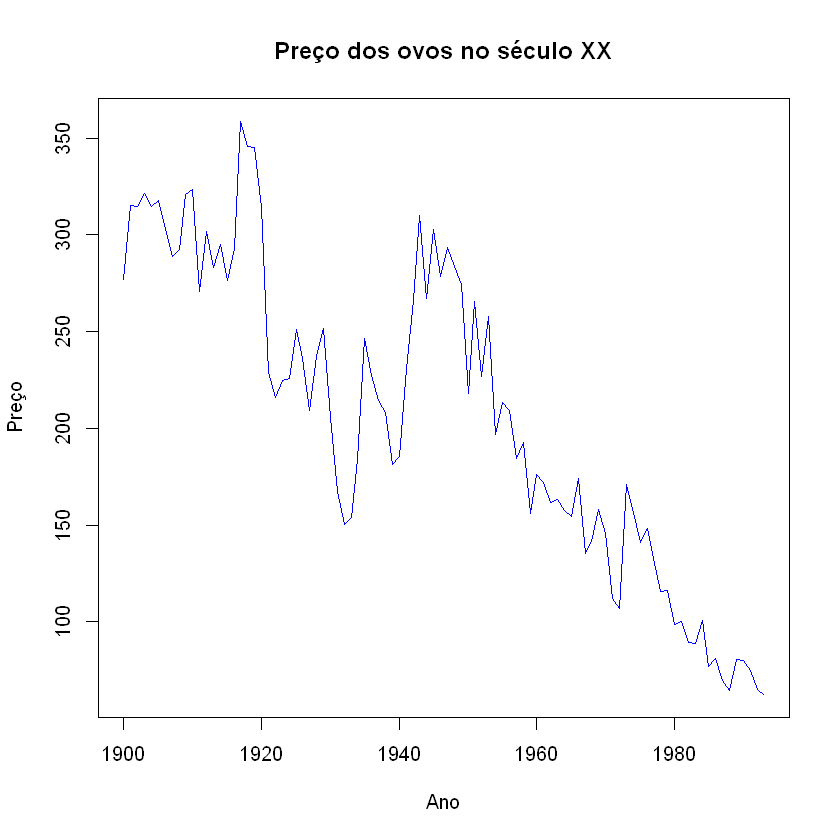

In [1]:
# Plotando a série temporal
dados <- read.csv("eggs.csv")
eggs <- ts(dados$y, start=1900)
plot(eggs,
     main='Preço dos ovos no século XX',
     xlab='Ano',
     ylab='Preço',
     col='blue')

Analisando a série temporal, podemos ver que a série possui uma **tendência decrescente**, em vista de que o preço dos ovos decaiu ao passar dos anos nessa década. Porém, é válido notar que a série possui algumas anormalidades, observadas em 2 picos de crescimento bruscos em meio à decaída dos preços: por volta de 1915 e 1945. Isso pode ser explicado pelas Guerras Mundiais ocorridas nesse período, justificativa plausível para a subida dos preços.

---

Sobre a variância da série, é possível observar que, exceto pelos picos durante os conflitos militares mencionados, sua variabilidade tem tendência a permanecer igual ao passar do tempo. Fazendo o gráfico de amplitude-média:



Call:
lm(formula = x.r ~ x.m)

Residuals:
    Min      1Q  Median      3Q     Max 
-35.991 -12.607  -6.555  10.561  76.038 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)   
(Intercept) 16.36252    6.64553   2.462   0.0157 * 
x.m          0.08200    0.03008   2.726   0.0077 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 22.43 on 90 degrees of freedom
Multiple R-squared:  0.07627,	Adjusted R-squared:  0.06601 
F-statistic: 7.431 on 1 and 90 DF,  p-value: 0.007705



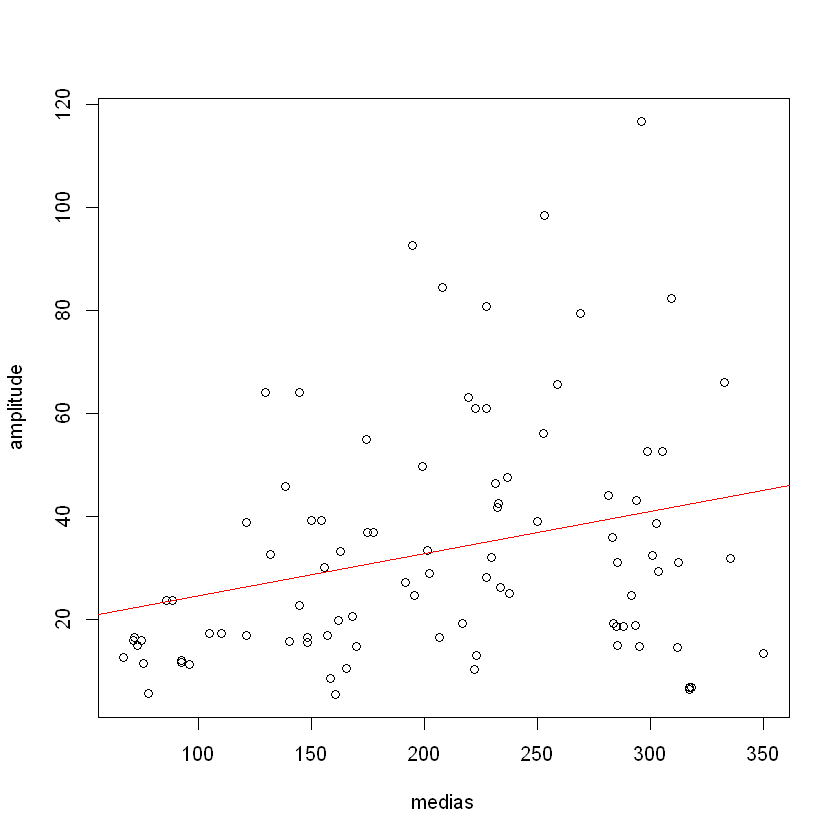

In [4]:
media.amplitude(eggs,2)

Para comprovar, podemos realizar a transformação de Box-Cox na série:

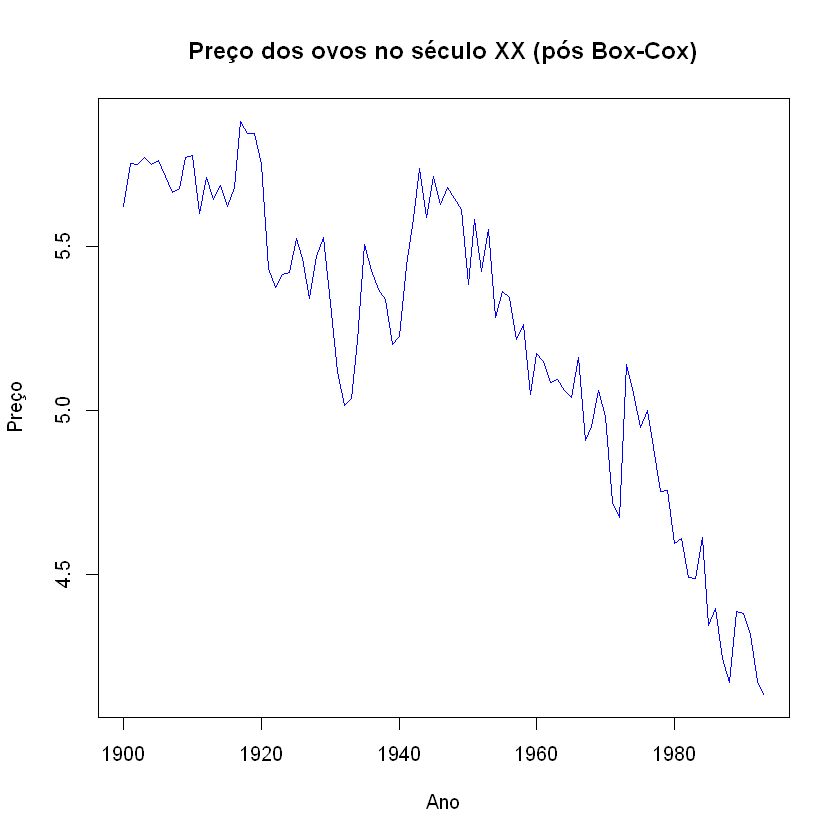

In [5]:
eggs2 <- log(eggs)
plot(eggs2,
     main='Preço dos ovos no século XX (pós Box-Cox)',
     xlab='Ano',
     ylab='Preço',
     col='blue')

Após o gráfico de amplitude-média e transformação Box-Cox, os picos de crescimento da série foram diminuídos, porém o comportamento geral da série pareceu não se alterar muito.

Para entender melhor o decrescimento da série, podemos observar no gráfico seguinte:


NULL


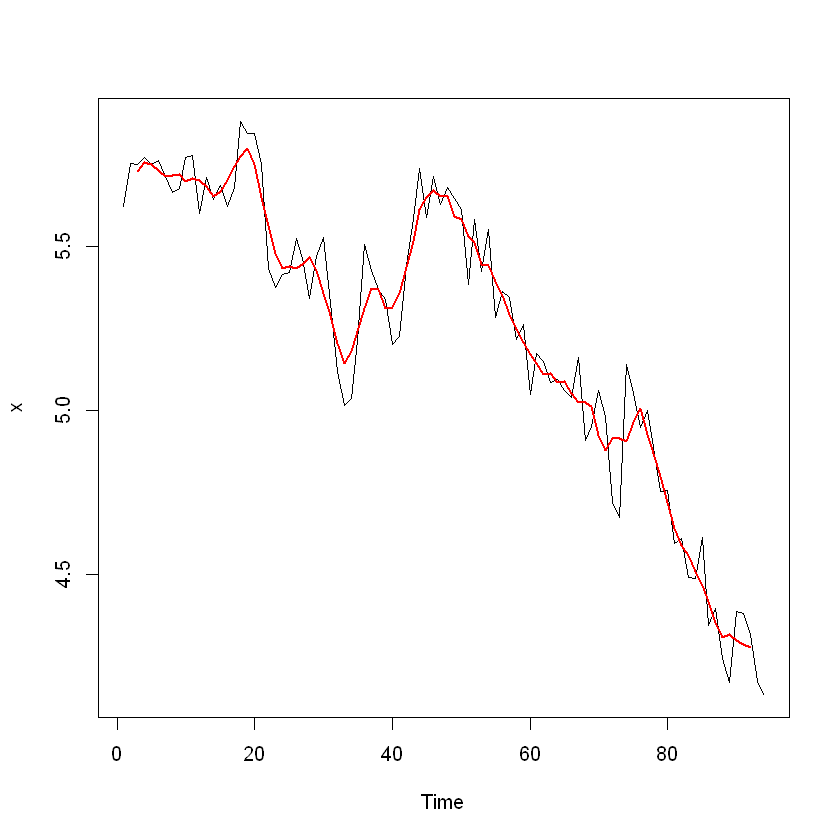

In [6]:
print(media.moveis(eggs2,2))

Como visto no gráfico, a média a cada 2 anos tende a decair, logo podemos concluir que a série é **decrescente**.

Para retirar a tendência da série, podemos usar a função $\texttt{diff(eggs)}$ para fazer a diferenciação dos valores da série e retirar a sua tendência, para que assim possamos analisar a série sem que os comportamentos sejam mascarados pela queda dos preços.


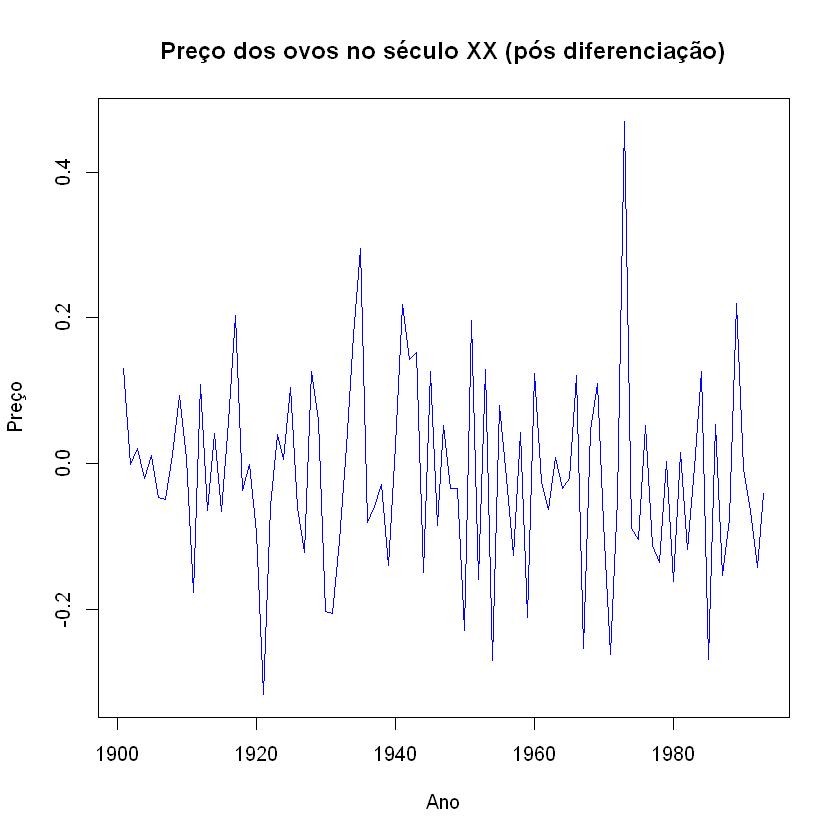

In [7]:
eggs3 <- diff(eggs2)
plot(eggs3,
     main='Preço dos ovos no século XX (pós diferenciação)',
     xlab='Ano',
     ylab='Preço',
     col='blue')

Verificando as médias:

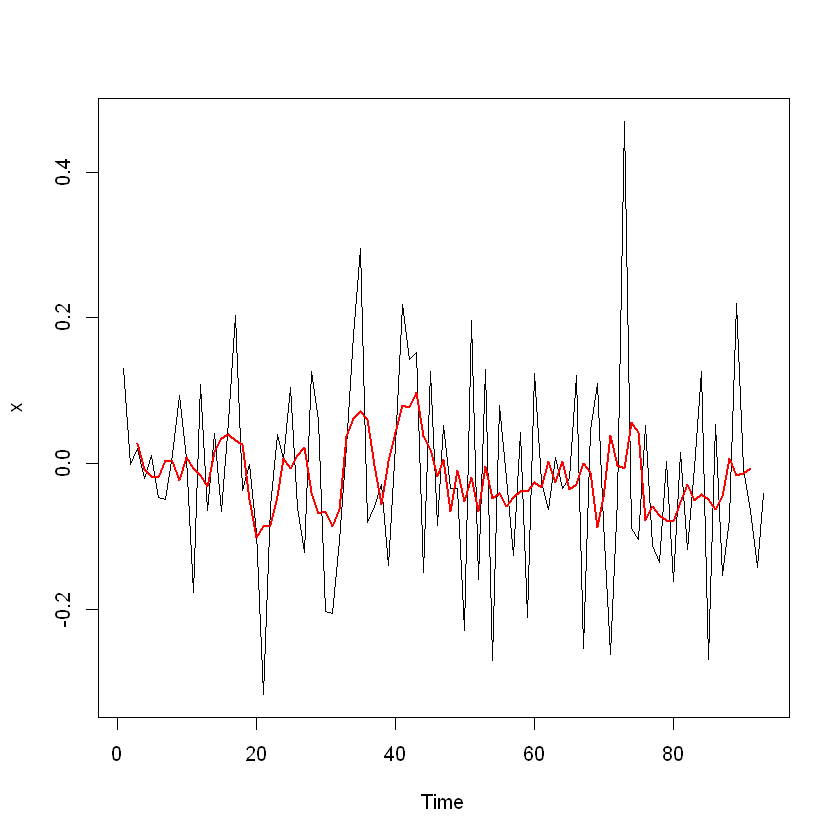

In [8]:
media.moveis(eggs3, 2)

Analisando os gráficos, podemos ver que a diferenciação auxiliou em retirar a tendência decrescente da série, deixando-a estacionária, pois a média da série temporal está em torno do zero.

Antes da diferenciação, podemos verificar apenas analisando a série que ela não é sazonal, pois decresce ao longo do tempo. Verificando a **sazonalidade** pós diferenciação:


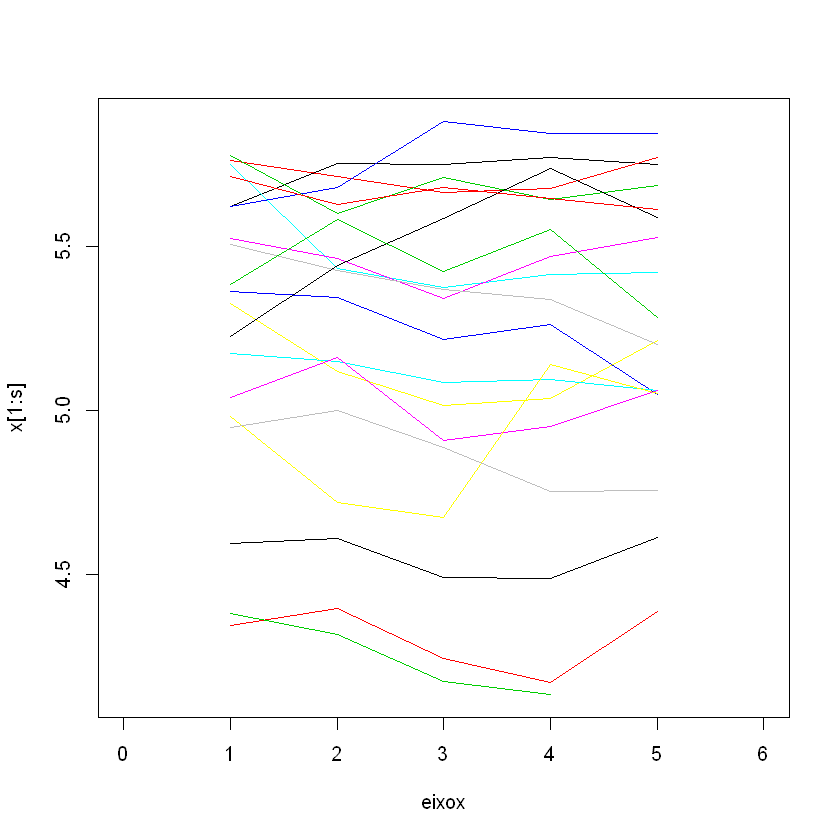

In [9]:
grafico.sazonalidade(eggs2,5)

Como as linhas estão embaralhadas e sem padrão evidente, concluímos que a série temporal não possui sazonalidade, mesmo após a diferenciação.

---

### **Série 2 - Número de pessoas que viajam para Sydney**

A série escolhida retrata quantidade de pessoas que viajam para Sydney durante os anos de 1998 a 2017.
 
Plotando os dados para visualizarmos o comportamente da série:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [ ]:
import pandas as pd
df = pd.read_csv('tourism.csv')
display(df.head())


,ds,Region,State,Purpose,y
0,1998-01-01,Adelaide,South Australia,Business,135.077690
1,1998-04-01,Adelaide,South Australia,Business,109.987316
2,1998-07-01,Adelaide,South Australia,Business,166.034687
3,1998-10-01,Adelaide,South Australia,Business,127.160464
4,1999-01-01,Adelaide,South Australia,Business,137.448533


In [ ]:
df[ 'ds'] = pd.to_datetime(df['ds'])
df = df[(df["Region"] == "Sydney") & (df["Purpose"] == "Holiday")]
df = df.sort_values("ds")
display(df.head())

,ds,Region,State,Purpose,y
21520,1998-01-01,Sydney,New South Wales,Holiday,828.317118
21521,1998-04-01,Sydney,New South Wales,Holiday,531.434192
21522,1998-07-01,Sydney,New South Wales,Holiday,502.870983
21523,1998-10-01,Sydney,New South Wales,Holiday,579.748044
21524,1999-01-01,Sydney,New South Wales,Holiday,465.497480


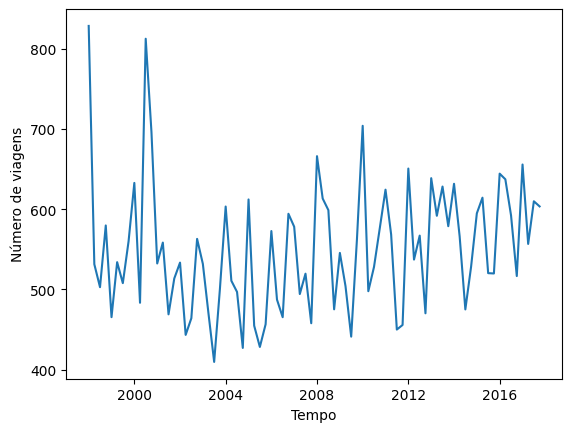

In [ ]:
plt.figure()
plt.plot(df['ds'], df['y'])
plt.xlabel("Tempo")
plt.ylabel("Número de viagens")
plt.show()

A série apresenta variações ao longo do tempo, com valores entre aproximadamente 400 e 830. Em relação à tendência, não há um crescimento ou queda fortemente definida em todo o intervalo. Quanto a sazonalidade, a série aparenta apresentar oscilações recorrentes, com picos e vales que se repetem ao longo dos anos. Apresenta alta variabilidade, alguns picos mais acentuados (como no início da série) podem indicar eventos atípicos ou variações específicas daquele período.

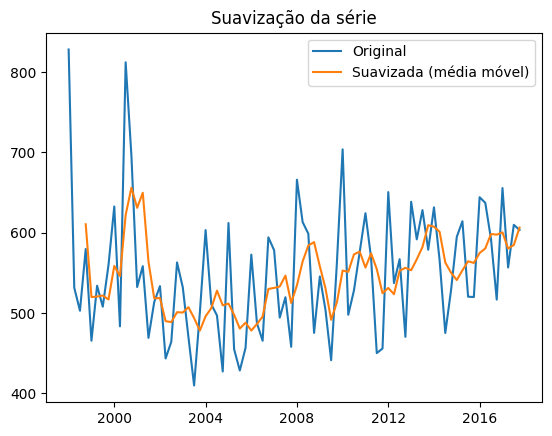

In [ ]:
df['media_movel'] = df['y'].rolling(window=4).mean()

plt.figure()
plt.plot(df['ds'], df['y'], label="Original")
plt.plot(df['ds'], df['media_movel'], label="Suavizada (média móvel)")
plt.legend()
plt.title("Suavização da série")
plt.show()

Para melhor visualizar o comportamento da série ao longo do tempo, foi aplicada uma média móvel, que reduz o ruído das oscilações de curto prazo e evidencia padrões mais estruturais. A suavização também evidencia que, apesar da alta variabilidade da série original, o nível médio permaneceu relativamente estável na segunda metade do período, sem tendência clara de crescimento ou declínio acentuado.

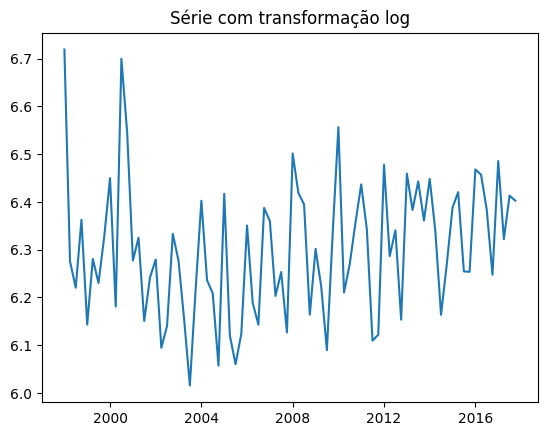

In [ ]:
df['log_y'] = np.log(df['y'])
plt.figure()
plt.plot(df['ds'], df['log_y'])
plt.title("Série com transformação log")
plt.show()

Para estabilizar a variância da série, foi aplicada a transformação logarítmica. Após a transformação, os valores passam a oscilar em uma faixa mais estreita (entre 6,0 e 6,7). O padrão geral da série se mantém: as oscilações recorrentes (sazonalidade) continuam visíveis, e a ausência de tendência clara também é preservada.

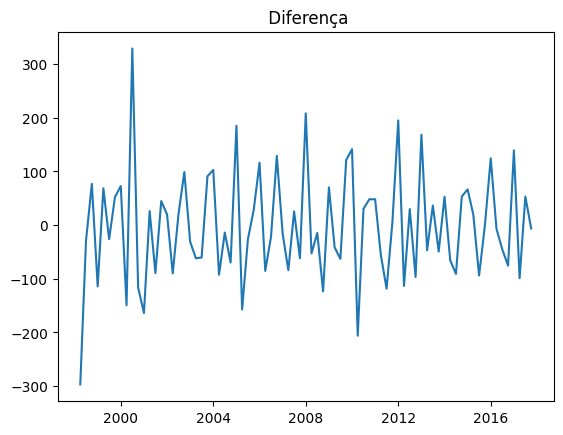

In [ ]:
df['diff1'] = df['y'].diff()
plt.figure()
plt.plot(df['ds'], df['diff1'])
plt.title(" Diferença")
plt.show()

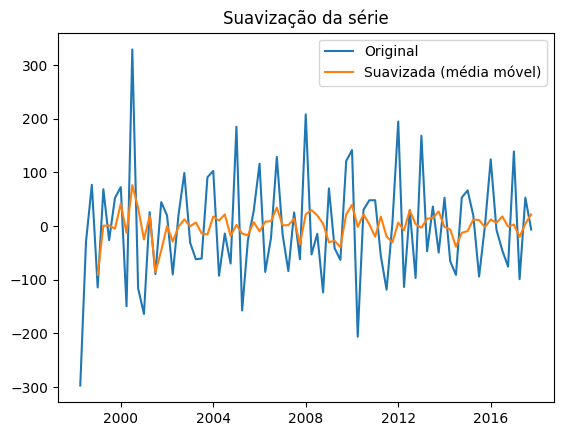

In [ ]:
df['media_movel'] = df['diff1'].rolling(window=4).mean()

plt.figure()
plt.plot(df['ds'], df['diff1'], label="Original")
plt.plot(df['ds'], df['media_movel'], label="Suavizada (média móvel)")
plt.legend()
plt.title("Suavização da série")
plt.show()

Para remover a tendência e buscar a estacionariedade da série, foi aplicada a diferenciação de primeira ordem. A série diferenciada passa a oscilar em torno de zero, sem nível crescente ou decrescente evidente, o que indica que a diferenciação foi eficaz em eliminar componentes não estacionários.
A média móvel aplicada sobre a série diferenciada reforça essa observação: a curva suavizada mantém-se próxima de zero ao longo de todo o período, confirmando a ausência de tendência.

In [ ]:
def grafico_sazonalidade(x, s):
    x = np.asarray(x, dtype=float)
    N = len(x)
    Mx = np.nanmax(x)
    mx = np.nanmin(x)
    valor = N // s
    eixox = np.arange(1, s + 1)

    plt.figure()
    for i in range(1, valor + 1):
        y = x[(i-1)*s : i*s]
        plt.plot(eixox, y, color=f"C{i}")

    # Último segmento residual
    restante = x[valor*s : N]
    if len(restante) > 0:
        plt.plot(np.arange(1, len(restante) + 1), restante, color=f"C{valor+1}")

    plt.ylim(mx, Mx)
    plt.xlim(0, s + 1)
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.title("Gráfico de Sazonalidade")
    plt.tight_layout()
    plt.show()


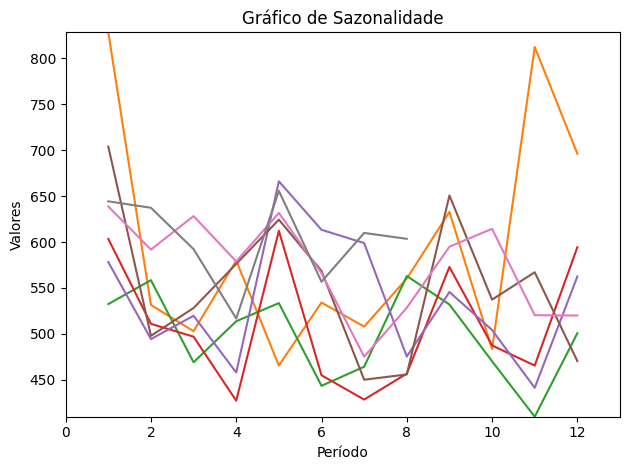

In [ ]:
grafico_sazonalidade(df["y"],12)

O gráfico de sazonalidade apresenta o comportamento da série ao longo dos 12 períodos (meses) para cada ano, permitindo identificar padrões que se repetem. Apesar de as linhas de diferentes anos não seguirem um padrão perfeitamente uniforme, o comportamento oscilatório recorrente reforça a presença de sazonalidade na série.

---

Série 3 - Quantidade de greves

A série escolhida retrata quantidade de greves por ano durante os anos de 1951 a 1980.
 
Plotando os dados para visualizarmos o comportamente da série:

In [ ]:
dados <- read.csv("strikes.csv")

greves <- ts(dados$y,start=c(1951,1))

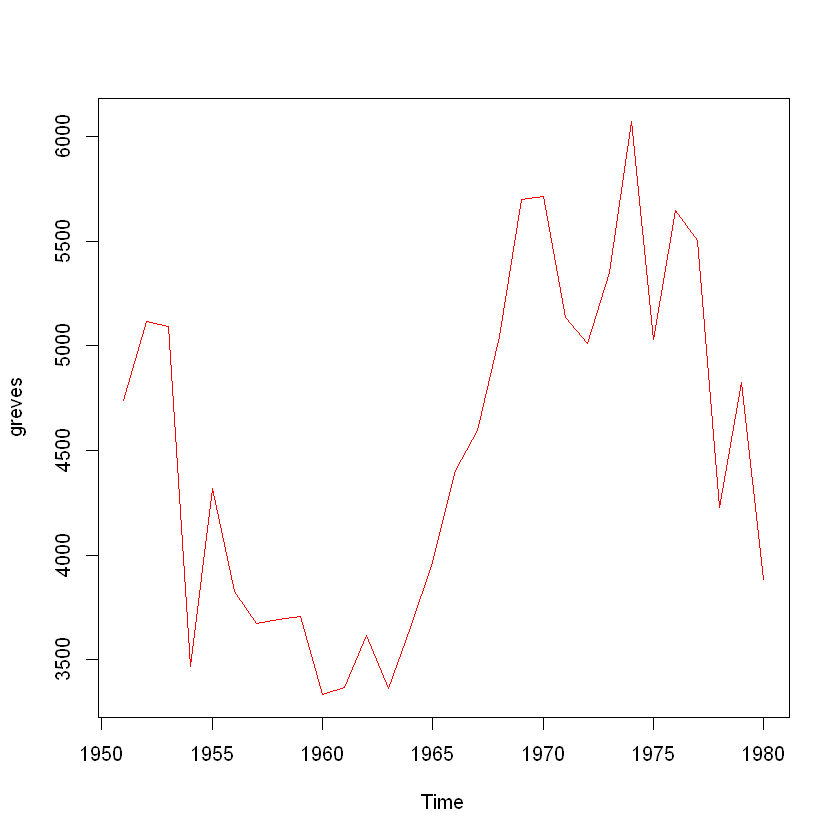

In [ ]:
ts.plot(greves,col = "red")

Ao analisar essa série temporal, percebemos que a série não apresenta uma tendência linear simples, e sim apresenta uma tendência não linear, com mudanças de direção ao longo do tempo.

Podemos dizer que a série não tem tendência determinística clara.

---

Fazendo as médias móveis com janela de 3 anos para visualizar a tendência.

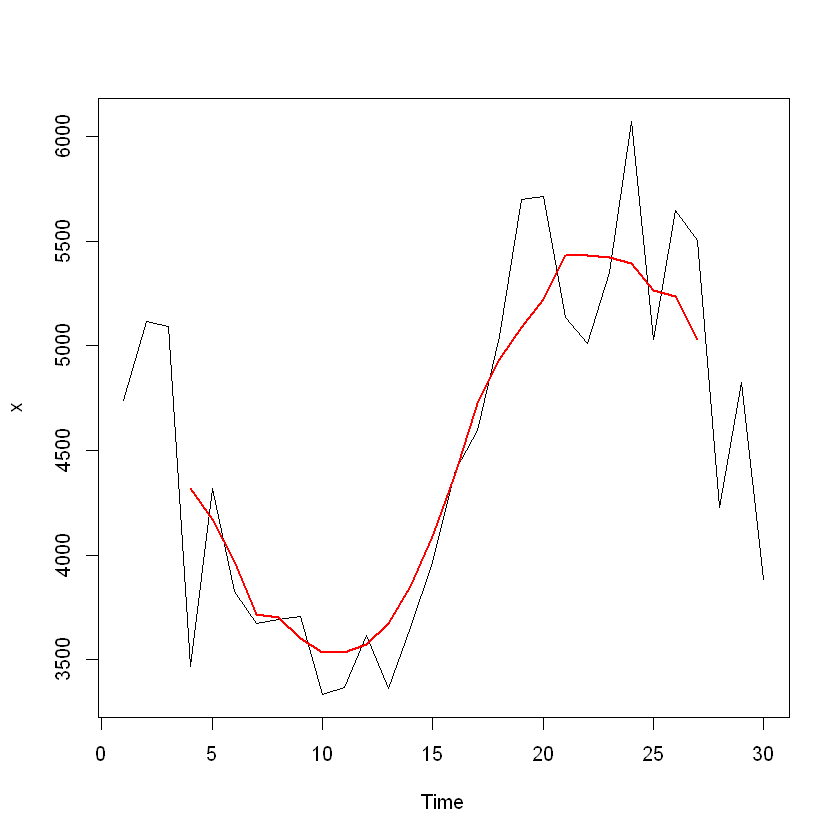

In [ ]:
media.moveis(greves,3)


Como visto no gráfico, ao longo do tempo a média a cada 3 anos não segue um tendência linear.

Em relação à sazonalidade, não há indícios visuais claras de sazonalidade (pelo menos no intervalo de tempo observado), o que é consistente com a natureza anual dos dados.

---

Fazendo o gráfico da média e amplitude para determinar $\lambda$ da transformação de Box-Cox


Call:
lm(formula = x.r ~ x.m)

Residuals:
    Min      1Q  Median      3Q     Max 
-550.52 -239.08  -71.15  166.59  948.61 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept) -401.95288  441.49514  -0.910   0.3710  
x.m            0.25072    0.09672   2.592   0.0154 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 389.5 on 26 degrees of freedom
Multiple R-squared:  0.2054,	Adjusted R-squared:  0.1748 
F-statistic:  6.72 on 1 and 26 DF,  p-value: 0.01544



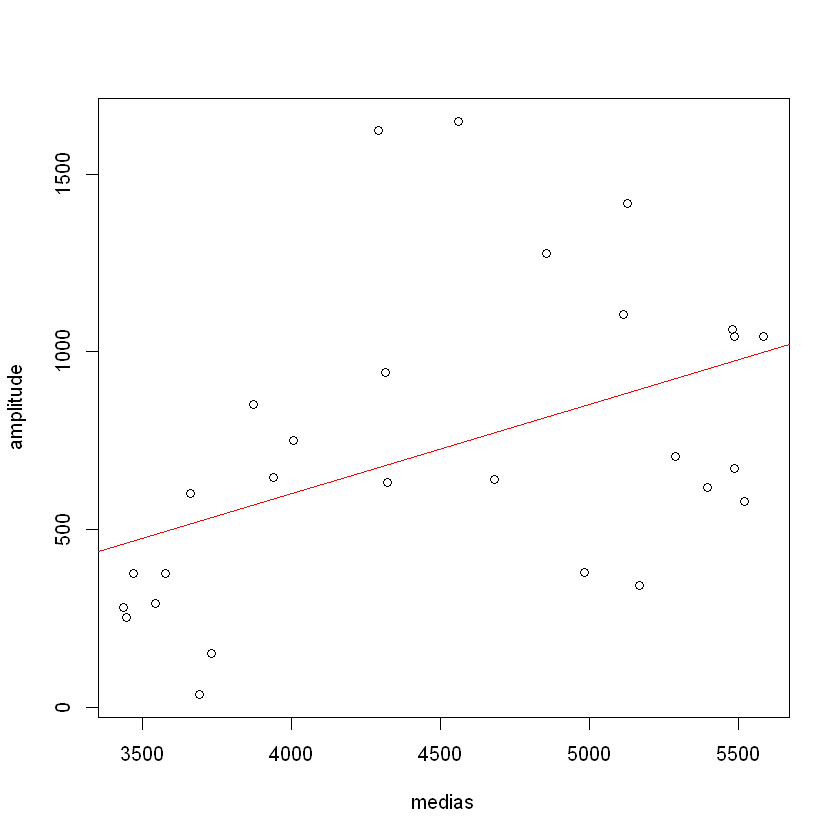

In [ ]:
media.amplitude(greves,2)

Fazendo transformação de Box-Cox para estabilizar a variação. ($\lambda= 0.25$)

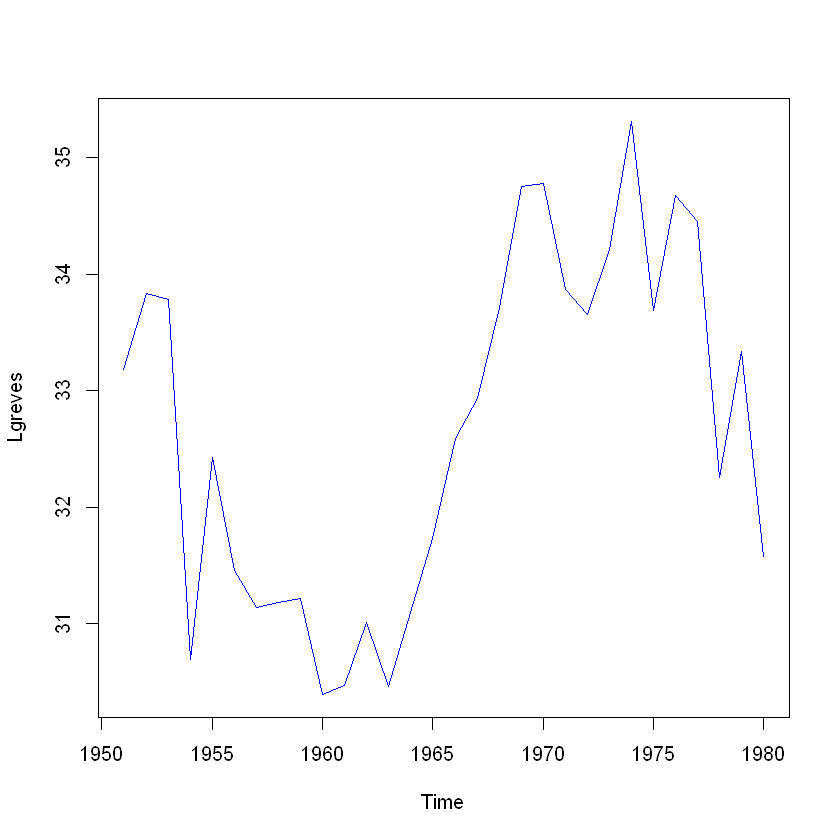

In [ ]:
Lgreves <- greves^0.25 /0.25
ts.plot(Lgreves,col = "blue")

Note que a transformação de Box-Cox não modificou o comportamento da série. 

---

Fazendo gráfico da diferença ao longo da série:

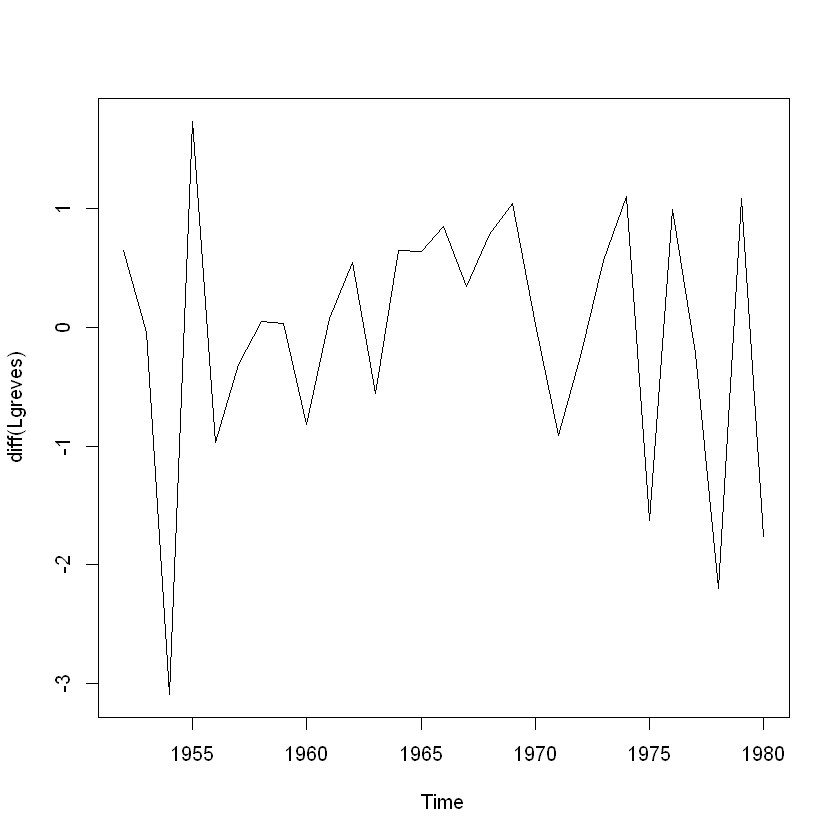

In [ ]:
plot(diff(Lgreves))

Olhando o gráfico da diferença podemos dizer que a variabilidade não é constante, já que parece que a média da diferença não está em torno de 0, ou seja há indícios visuais de variação na dispersão.

---

Por fim temos indícios visuais de que a série não tem tendência linear, é heterocedástica, e não sazonal.

---

In [3]:
media.amplitude<-function(x,k)
{N<-length(x)
x.m<-rep(0,(N-k))
x.r<-rep(0,(N-k))
for (i in 1:(N-k)) x.m[i]<-mean(x[i:(i+k)])
for (i in 1:(N-k)) x.r[i]<-max(x[i:(i+k)])-min(x[i:(i+k)])
plot(x.m,x.r,xlab="medias",ylab="amplitude")
aa1<-lm(x.r~x.m)
print(summary(aa1))
abline(aa1$coef[1],aa1$coef[2],col=2)
}
media.moveis<-function(x,k)
{x<-as.vector(x)
N<-length(x)
xstar<-rep(0,N)
for (i in 1:k) xstar[i]<-NA
for (i in (1+k):(N-k)) xstar[i]<-mean(x[(i-k):(i+k)],na.rm=TRUE)
for (i in (N-k+1):N) xstar[i]<-NA
ts.plot(x)
lines(xstar, col=2, lwd=2)}

mediana.bloco<-function(x,k)
{x<-as.vector(x)
N<-length(x)
xstar<-rep(0,N)
for (i in 1:k) xstar[i]<-NA
for (i in (1+k):(N-k)) xstar[i]<-median(x[(i-k):(i+k)],na.rm=TRUE)
for (i in (N-k+1):N) xstar[i]<-NA
ts.plot(x)
lines(xstar, col=2, lwd=2)
}
grafico.sazonalidade<-function(x,s){
  x<-as.vector(x)
  N<-length(x)
  Mx<-max(x)
  mx<-min(x)
  valor<-N%/%s
  eixox<-seq(1:s)
  plot(eixox,x[1:s],ylim=c(mx,Mx),xlim=c(0,(s+1)),type="l")
  for (i in 1:valor){
    y<-rep(NA,s)
    y[1:s]<-x[((i-1)*s+1):(i*s)]
     lines(y,col=i)
  }
  y<-rep(NA,s)
  y<-x[(valor*s+1):N]
  lines(y,col=(valor+1))
}